We take the 2-layer MLP from previous video and make it deeper with a tree-like structure, arriving at a convolutional neural network architecture similar to the WaveNet (2016) from DeepMind. In the WaveNet paper, the same hierarchical architecture is implemented more efficiently using causal dilated convolutions (not yet covered). Along the way we get a better sense of torch.nn and what it is and how it works under the hood

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [35]:
# block_size = 3
block_size = 8

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for c in w + '.':
            ix = stoi[c]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])
print(f"Xtr.shape, Ytr.shape: {Xtr.shape, Ytr.shape}")
print(f"Xdev.shape, Ydev.shape: {Xdev.shape, Ydev.shape}")
print(f"Xte.shape, Yte.shape: {Xte.shape, Yte.shape}")

Xtr.shape, Ytr.shape: (torch.Size([182441, 8]), torch.Size([182441]))
Xdev.shape, Ydev.shape: (torch.Size([22902, 8]), torch.Size([22902]))
Xte.shape, Yte.shape: (torch.Size([22803, 8]), torch.Size([22803]))


In [31]:
import torch
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / ((fan_in)**0.5)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d: #https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True # pytorch moduels behave differently when in training or eval mode
        # learnable parameters via backprop
        self.gamma = torch.ones((dim))
        self.beta = torch.zeros((dim))
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros((dim)) # trained internally using exp moving average
        self.running_var = torch.ones((dim))

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # mean over batch
            xvar = x.var(0, keepdim=True) # variance over batch
        else:
            xmean= self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        #update buffers
        with torch.no_grad():
            # exponential moving average ()
            self.running_mean = (1 - self.momentum) * self.running_mean +  self.momentum * xmean
            self.running_var = (1 - self.momentum) *self.running_var +  self.momentum + xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []


In [32]:
torch.manual_seed(42)

In [12]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

C = torch.randn((vocab_size, n_embd))
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size, bias=False),
]
with torch.no_grad():
    layers[-1].weight *= 0.1 # last layer make less confident

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12070


In [15]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = [] # grad update to data ratio

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters]) #  to visualise grad update to data

  # if i >= 1000: # to visualise the grad to data ratio
  #   break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.3204
  10000/ 200000: 2.0320
  20000/ 200000: 2.0834
  30000/ 200000: 2.0616
  40000/ 200000: 2.2939
  50000/ 200000: 2.3946
  60000/ 200000: 2.0667
  70000/ 200000: 2.1076
  80000/ 200000: 2.6080
  90000/ 200000: 2.1653
 100000/ 200000: 2.0498
 110000/ 200000: 2.2507
 120000/ 200000: 1.8601
 130000/ 200000: 1.9640
 140000/ 200000: 2.2551
 150000/ 200000: 2.0346
 160000/ 200000: 1.7647
 170000/ 200000: 1.6389
 180000/ 200000: 2.6084
 190000/ 200000: 2.1836


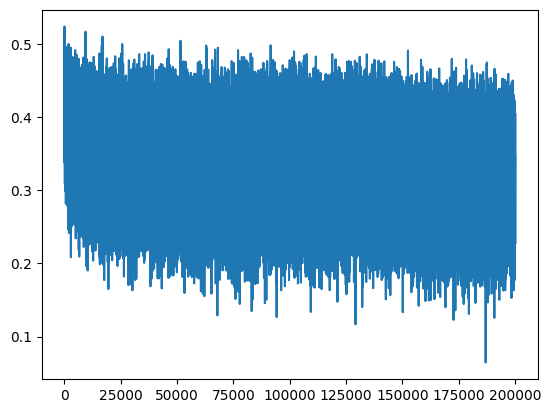

In [16]:
plt.plot(lossi)

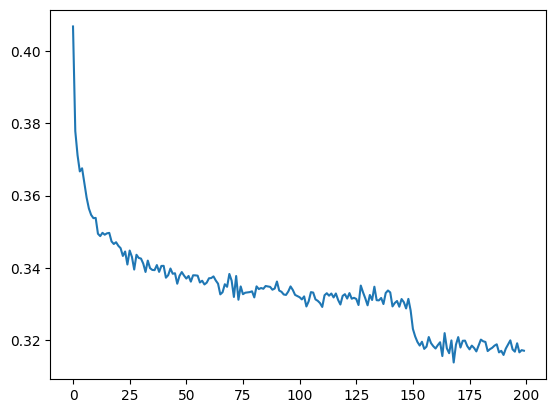

In [ ]:
# lets fix this plto first 
# we take the mean on every row and plot
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
# sudden drop is lr decay

In [62]:
# now let's move embeddign layers into the model
# we creat modules for embeddigns lookup and embedding flattening
# -----------------------------------------------------------------------------------------------

class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / ((fan_in)**0.5)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d: #https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True # pytorch moduels behave differently when in training or eval mode
        # learnable parameters via backprop
        self.gamma = torch.ones((dim))
        self.beta = torch.zeros((dim))
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros((dim)) # trained internally using exp moving average
        self.running_var = torch.ones((dim))

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # mean over batch
            xvar = x.var(0, keepdim=True) # variance over batch
        else:
            xmean= self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        #update buffers
        with torch.no_grad():
            # exponential moving average ()
            self.running_mean = (1 - self.momentum) * self.running_mean +  self.momentum * xmean
            self.running_var = (1 - self.momentum) *self.running_var +  self.momentum + xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

# -----------------------------------------------------------------------------------------------
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
    
  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
# class Flatten:
    
#   def __call__(self, x):
#     self.out = x.view(x.shape[0], -1)
#     return self.out
  
#   def parameters(self):
#     return []

class FlattenConsecutive: # this is different to torch.flatten()

  def __init__(self, n):
    self.n = n
    
  def __call__(self, x):
    B, T, C = x.shape
    # x = x.view(B, -1, C*n) # C*n = how many consectutive elements we want to flatten, we replace -1 with T//n
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1: # if T//n is 1, we squeeze the middle dimension
      x = x.squeeze(1)
    self.out = x
    return self.out
  
  def parameters(self):
    return []


# -----------------------------------------------------------------------------------------------
class Sequential: # https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html 
  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
      self.out = x      
    return self.out
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [55]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

# note removed the C and flattening
layers = [
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(block_size),
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size, bias=False),
]
with torch.no_grad():
    layers[-1].weight *= 0.1 # last layer make less confident

parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22070


In [ ]:
# let's see the forward pass of the mdoel
ix = torch.randint(0, Xtr.shape[0], (4,)) # a batch of 4 examples
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb



torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  2, 18,  9, 20, 20,  5, 14],
        [ 0,  0,  0,  0,  0,  0, 10,  1],
        [ 0,  0,  0,  0,  0,  7,  9,  1]])

In [ ]:
model.layers[0].out.shape # output of embedding layer
# embedding layer takes integers indices and plucks out the corresponding row from the embedding matrix
# so the output shape is (4, 8, 10)
# 4 is the batch size, 8 is the block size, and 10 is the embedding dimension




torch.Size([4, 8, 10])

In [42]:
model.layers[1].out.shape # output of flatten layer
# flatten layer takes the 4, 8, 10 and flattens it into 4, 80
# 4 is the batch size, and 80 is the number of features


torch.Size([4, 80])

In [ ]:
model.layers[2].out.shape # output of first linear layer
# the linear layer takes the 4, 80 and applies a matrix multiplication with the weight matrix
# the weight matrix is of shape (80, 200)
# so the output shape is (4, 200)
# inside the Linera layer x(4,80) @ W(80,200) + bias(200,) = (4,200)
#(torch.randn((4,80)) @ torch.randn((80,200)) + torch.randn((200,)))
# pythorch matrix multiplication i squite powerful. the INPUT LAYE DOES NOT HAVE TO BE 2-dimensional. it can be any arbitrary dimension 
# @ will broadcast the matrix across the additional dimensions

torch.Size([4, 200])

In [ ]:
# (torch.randn((4,80)) @ torch.randn((80,200)) + torch.randn((200,))).shape
(torch.randn((4,5,5,80)) @ torch.randn((80,200)) + torch.randn((200,))).shape

# this is convenient as we we can introduce batch dimentions in the input layer and not have to change the rest of the model
# we have 8 block size, we can have 4 tuples of bigrams
# we don't want 80 charactesers at the input and get squashed byt he netowrk, we want 2 characters and then get infused with the network

# input is 4 groups of 2 iwth 10 dimention each
(torch.randn((4,4, 20)) @ torch.randn((20,200)) + torch.randn((200,))).shape

# we need to change the input layer and flatten layer

torch.Size([4, 4, 200])

In [ ]:
e = torch.randn(4,8,10) # goal is to get (4,4,20) wehre consective 10-d vectors are concatenated
print(list(range(10))[::2]) # gives even parts
print(list(range(10))[1::2]) # gives odd parts
# similarly we can do this for the embedding layer
e[:, ::2, :] # even characters
e[:, 1::2, :] # odd characters
# now concatenate the even and odd parts along the embedding dimension
explicit = torch.cat((e[:, ::2, :], e[:, 1::2, :]), dim=2)
e.shape

# we can also use view to do this 
(e.view(4,4,20) == explicit).all()

# let's change the flatten layer

[0, 2, 4, 6, 8]
[1, 3, 5, 7, 9]


tensor(True)

In [ ]:
class Flatten: # it departs form pytoprch
    
  def __call__(self, x):
    self.out = x.view(x.shape[0], -1)
    return self.out
  
  def parameters(self):
    return []


In [78]:
# put layers into pytorch containers such as sequential
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of the MLP, 68 worked better for thsi model

# note removed the C and flattening
layers = [
  Embedding(vocab_size, n_embd),
  # we want to flatten consective by 2 for wavenet like architecture not hte blcok size 
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size, bias=False),
]
model = Sequential(layers)

with torch.no_grad():
    layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters() #NOTE: we don't need to flatten the parameters
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22370


In [80]:
# Run a forward pass first to populate layer.out attributes
ix = torch.randint(0, Xtr.shape[0], (32,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)

for layer in model.layers:
    print(layer.__class__.__name__, ":", tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
FlattenConsecutive : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
FlattenConsecutive : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 27)


In [ ]:
# wehn the Batchnorm was implmented, we assumed 2D input but nbow we have 3D input
#it works becuse everything is broadcasted
# class BatchNorm1d: #https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html
#     def __init__(self, dim, eps=1e-5, momentum=0.1):
#         self.eps = eps
#         self.momentum = momentum
#         self.training = True # pytorch moduels behave differently when in training or eval mode
#         # learnable parameters via backprop
#         self.gamma = torch.ones((dim))
#         self.beta = torch.zeros((dim))
#         # buffers (trained with a running 'momentum update')
#         self.running_mean = torch.zeros((dim)) # trained internally using exp moving average
#         self.running_var = torch.ones((dim))

#     def __call__(self, x):
#         # forward pass
#         if self.training:
#             xmean = x.mean(0, keepdim=True) # mean over batch
#             xvar = x.var(0, keepdim=True) # variance over batch
#         else:
#             xmean= self.running_mean
#             xvar = self.running_var
#         xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
#         self.out = self.gamma * xhat + self.beta
#         #update buffers
#         with torch.no_grad():
#             # exponential moving average ()
#             self.running_mean = (1 - self.momentum) * self.running_mean +  self.momentum * xmean
#             self.running_var = (1 - self.momentum) *self.running_var +  self.momentum + xvar
#         return self.out
    
#     def parameters(self):
#         return [self.gamma, self.beta]



e = torch.randn(32, 4, 68)
emean = e.mean(0, keepdim=True) #(1,4,68)
evar = e.var(0, keepdim=True) #(1,4,68)
model.layers[3].running_mean.shape # (1, 4, 68) we have an array of 4,68 instead of 68 running means
# so we don't want to average over 32 but we want to average 32 x 4 over 68 channels : https://youtu.be/t3YJ5hKiMQ0
# so we need to average over tuple
emean = e.mean((0, 1), keepdim=True) #(1,1,68)
evar = e.var((0, 1), keepdim=True) #(1,1,68)
evar.shape
# now let's change the implmentation of Batchnorm 

torch.Size([1, 1, 68])

In [95]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / ((fan_in)**0.5)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d: 
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True # pytorch moduels behave differently when in training or eval mode
        # learnable parameters via backprop
        self.gamma = torch.ones((dim))
        self.beta = torch.zeros((dim))
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros((dim)) # trained internally using exp moving average
        self.running_var = torch.ones((dim))

    def __call__(self, x):
        # forward pass
        # fix for 3d input
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1) # here we depart from torch.nn.BatchNorm1d as its input shape has (N,C,L) wehre C channels is at 1, 
            xmean = x.mean(dim, keepdim=True) # mean over batch
            xvar = x.var(dim, keepdim=True) # variance over batch
        else:
            xmean= self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        #update buffers
        with torch.no_grad():
            # exponential moving average ()
            self.running_mean = (1 - self.momentum) * self.running_mean +  self.momentum * xmean
            self.running_var = (1 - self.momentum) *self.running_var +  self.momentum + xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

# -----------------------------------------------------------------------------------------------
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
    
  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------


class FlattenConsecutive: # this is different to torch.flatten()

  def __init__(self, n):
    self.n = n
    
  def __call__(self, x):
    B, T, C = x.shape
    # x = x.view(B, -1, C*n) # C*n = how many consectutive elements we want to flatten, we replace -1 with T//n
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1: # if T//n is 1, we squeeze the middle dimension
      x = x.squeeze(1)
    self.out = x
    return self.out
  
  def parameters(self):
    return []


# -----------------------------------------------------------------------------------------------
class Sequential: # https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html 
  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
      self.out = x      
    return self.out
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [96]:
# put layers into pytorch containers such as sequential
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP, 68 worked better for thsi model

# note removed the C and flattening
layers = [
  Embedding(vocab_size, n_embd),
  # we want to flatten consective by 2 for wavenet like architecture not hte blcok size 
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size, bias=False),
]
model = Sequential(layers)

with torch.no_grad():
    layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters() #NOTE: we don't need to flatten the parameters
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

76552


In [86]:
# Run a forward pass first to populate layer.out attributes
ix = torch.randint(0, Xtr.shape[0], (32,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)

for layer in model.layers:
    print(layer.__class__.__name__, ":", tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
FlattenConsecutive : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
FlattenConsecutive : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 27)


In [97]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
#   emb = C[Xb] # embed the characters into vectors
#   x = emb.view(emb.shape[0], -1) # concatenate the vectors
  # x = Xb # we don't need to do lookup and flattening outside of layers

  # for layer in layers:
  #   x = layer(x)
  # loss = F.cross_entropy(x, Yb) # loss function
  

  # now jsut use model
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  
  

      0/ 200000: 3.2974
  10000/ 200000: 1.9394
  20000/ 200000: 1.9219
  30000/ 200000: 1.9629
  40000/ 200000: 1.6243
  50000/ 200000: 2.1690
  60000/ 200000: 1.9455
  70000/ 200000: 2.2425
  80000/ 200000: 1.9301
  90000/ 200000: 1.7841
 100000/ 200000: 1.6626
 110000/ 200000: 2.1521
 120000/ 200000: 1.9219
 130000/ 200000: 1.9945
 140000/ 200000: 2.1197
 150000/ 200000: 1.9599
 160000/ 200000: 1.8055
 170000/ 200000: 2.0045
 180000/ 200000: 1.6455
 190000/ 200000: 1.8387


In [98]:
# put layers into eval mode (needed for batchnorm layers especially)
for layer in layers:
    layer.traning = False

In [99]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  # emb = C[x] # (N, block_size, n_embd)
  # x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  # for layer in layers:
  #   x = layer(x)
  # now use model
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

# # put layers into eval mode
# for layer in layers:
#   layer.training = False
split_loss('train')
split_loss('val')

train 1.766809344291687
val 1.985120177268982


## Performance log
- original (3 character length + 200 neurons, 12k parameters): train , val
- context 3 -> 8 (22k parameters) train: 1.917, val: 2.02
- flat -> hierarchical (22k parameters) train: 1.938, val: 2.0231 (no improvement) there might be a bug in Batchnorm
- fix bug in batch norm: train:1.911 , val: 2.015
- scale up netowrk with 24 blocksize and 128 neurosn: train: 1.766 val: 1,985

In [91]:
# we did not implment the residual connections part of the Wavenet paper
# convolution is a "for loop"
# it allows to forward Linear layers efficiently over space
#EXAMPLE
for x,y in zip(Xtr[7:15],Ytr[7:15]):
    print(''.join(itos[i.item()] for i in x), '--->', itos[y.item()])



.elianys ---> .
........ ---> t
.......t ---> r
......tr ---> o
.....tro ---> y
....troy ---> .
........ ---> m
.......m ---> a


In [93]:
# forward a single example
logits = model(Xtr[[5]]) # note we use Xtr[[5]] to convert to tensor (1,27)
logits.shape

/var/folders/d6/c4t2t8r95k5_1glx_t5rnjgr0000gn/T/ipykernel_19658/4201228217.py:38: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  xvar = x.var(dim, keepdim=True) # variance over batch


torch.Size([1, 27])

In [ ]:
logits = torch.zeros((8,27))
for i in range(8):
    logits[i] = model(Xtr[[7+i]])
logits.shape

# our implmentation is 8 calls to our model, but convolution allows us to slide this model over space in one call
# this is done inside the kernel in cuda


In [90]:
# sample from the model

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      # emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      # x = emb.view(emb.shape[0], -1) # concatenate the vectors
      # for layer in layers:
      #   x = layer(x)
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

/var/folders/d6/c4t2t8r95k5_1glx_t5rnjgr0000gn/T/ipykernel_19658/4201228217.py:38: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  xvar = x.var(dim, keepdim=True) # variance over batch


RuntimeError: probability tensor contains either `inf`, `nan` or element < 0